In [1]:
import numpy as np
import pandas as pd
#import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [2]:
df_feat = pd.read_csv(r'E:\Users\Avishka\JobData\MyProjects\ml-model\data\Processed-Telco-Customer-Churn.csv')


C:\Users\Avishka Koswaththa\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters found: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 393}
Optimal threshold by F1-score: 0.5099999999999998
--- Training Set ---
ROC AUC: 0.9431392068754592
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      4139
           1       0.68      0.88      0.77      1495

    accuracy                           0.86      5634
   macro avg       0.82      0.86      0.83      5634
weighted avg       0.88      0.86      0.86      5634

Confusion Matrix:
 [[3522  617]
 [ 184 1311]]


--- Test Set ---
ROC AUC: 0.8416698958898448
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      

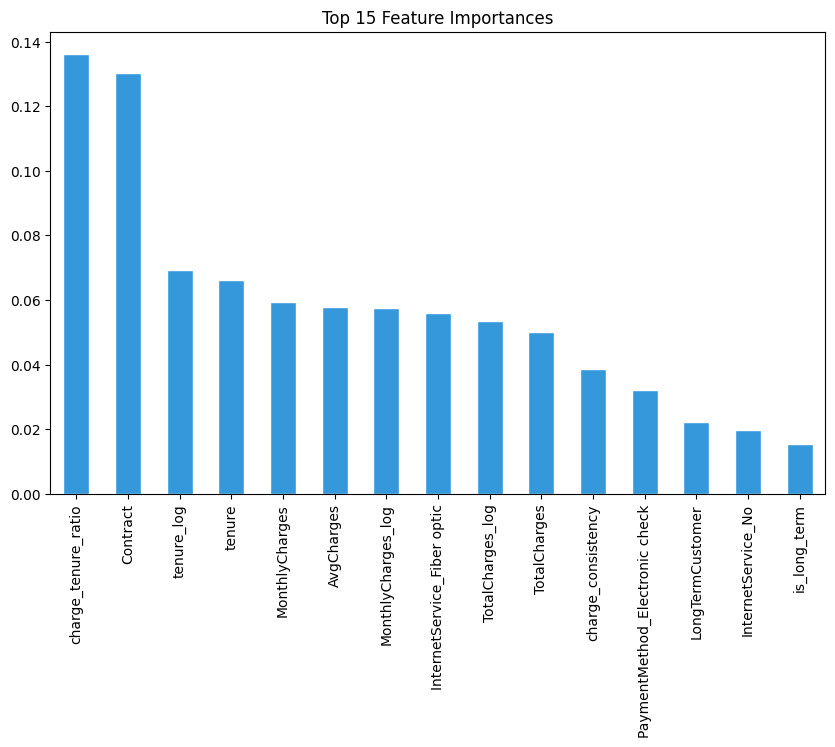

In [3]:
# ------------------------------
# 1️⃣ Imports
# ------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from scipy.stats import randint
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import f1_score


# ------------------------------
# 2️⃣ Features & Target
# ------------------------------
target_col = 'Churn'
feature_cols = [c for c in df_feat.columns if c != target_col]

X = df_feat[feature_cols].values
y = df_feat[target_col].values

# ------------------------------
# 3️⃣ Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# 4️⃣ Randomized Search for Hyperparameters
# ------------------------------
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X_train, y_train)

best_clf = random_search.best_estimator_
print("Best parameters found:", random_search.best_params_)

# ------------------------------
# 5️⃣ Threshold Tuning
# ------------------------------
y_proba_test = best_clf.predict_proba(X_test)[:,1]

# Try multiple thresholds to optimize churn recalle

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)
for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
print("Optimal threshold by F1-score:", best_threshold)

# Apply best threshold
y_pred_test = (y_proba_test >= best_threshold).astype(int)

# ------------------------------
# 6️⃣ Evaluation Function
# ------------------------------
def evaluate(model, X, y, y_pred=None, dataset_name="Dataset"):
    if y_pred is None:
        y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:,1]
    print(f"--- {dataset_name} ---")
    print("ROC AUC:", roc_auc_score(y, y_proba))
    print(classification_report(y, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\n")

evaluate(best_clf, X_train, y_train, y_pred=(best_clf.predict_proba(X_train)[:,1] >= best_threshold).astype(int), dataset_name="Training Set")
evaluate(best_clf, X_test, y_test, y_pred=y_pred_test, dataset_name="Test Set")

# ------------------------------
# 7️⃣ Feature Importances
# ------------------------------
feat_importance = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_importance[:15].plot(kind='bar', color='#3498db', edgecolor='white')
plt.title("Top 15 Feature Importances")
plt.show()

# ------------------------------
# 8️⃣ SHAP Analysis
# ------------------------------
# explainer = shap.TreeExplainer(best_clf)
# shap_values = explainer.shap_values(X_test)

# # Summary plot for class 1 (churn)
# shap.summary_plot(shap_values[1], X_test, feature_names=feature_cols)

In [6]:
# ------------------------------
# 9️⃣ Save the trained model
# ------------------------------
import joblib
import os

# Make sure the folder exists
model_dir = r"E:\Users\Avishka\JobData\MyProjects\ml-model\models"
os.makedirs(model_dir, exist_ok=True)

model_filename = os.path.join(model_dir, "random_forest_churn_model.pkl")

# Save the model
joblib.dump({"model": best_clf, "features": feature_cols, "threshold": best_threshold}, model_filename)
print(f"Model saved to {model_filename}")

Model saved to E:\Users\Avishka\JobData\MyProjects\ml-model\models\random_forest_churn_model.pkl


In [ ]:
# Load the model
loaded_model = joblib.load("random_forest_churn_model.pkl")

# Make predictions
y_proba_test_loaded = loaded_model.predict_proba(X_test)[:,1]
y_pred_test_loaded = (y_proba_test_loaded >= best_threshold).astype(int)